In [1]:
import duckdb
import pandas as pd

In [2]:
trans = pd.read_parquet("https://minio.lab.sspcloud.fr/projet-funathon/2026/project1/data/1_input/transactions_EN.parquet")
trans.shape
print(f"number of rows: {trans.shape[0]}")
print(f"number of columns: {trans.shape[1]}")
print("=" * 60)
print(f"=======================Data distribution====================")
print("=" * 60)
trans.describe()

number of rows: 9999635
number of columns: 43
=======================Data distribution====================


,trans_year,trans_month,price,prop_type,prop_year_harm,prop_loc_x,prop_loc_y,dist_tosea,n_floors,n_bath,...,nth_floor,s_land_artif,s_land_agri,s_land_nat,n_garage,n_pool,n_terrace,n_attic,n_basmt,n_otherannex
count,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.986618e+06,9.986618e+06,9.986618e+06,9.999635e+06,9.999635e+06,...,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06
mean,2.017001e+03,6.522953e+00,2.402853e+05,1.400009e+00,1.947800e+03,2.359369e+00,4.648919e+01,8.124287e+03,2.360037e+00,6.714670e-01,...,1.033532e+00,5.055850e+02,6.610428e+02,8.130392e+01,6.733883e-01,3.964305e-02,2.284278e-01,3.575668e-01,4.887532e-01,4.949211e-02
std,4.320021e+00,3.447693e+00,2.231492e+05,4.898999e-01,6.709590e+01,5.261263e+00,4.797850e+00,3.517539e+03,2.448644e+00,5.181332e-01,...,3.936771e+00,1.302745e+03,1.109009e+04,3.772332e+03,5.966201e-01,1.951191e-01,4.394879e-01,5.194642e-01,6.196501e-01,2.450435e-01
min,2.010000e+03,1.000000e+00,2.566987e+03,1.000000e+00,1.200000e+03,-6.314683e+01,-2.138736e+01,2.455657e-04,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.013000e+03,4.000000e+00,1.171319e+05,1.000000e+00,1.918000e+03,5.278337e-01,4.474772e+01,1.000000e+04,1.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.017000e+03,7.000000e+00,1.858936e+05,1.000000e+00,1.971000e+03,2.381033e+00,4.722144e+01,1.000000e+04,2.000000e+00,1.000000e+00,...,0.000000e+00,1.810000e+02,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.021000e+03,1.000000e+01,2.918414e+05,2.000000e+00,1.995000e+03,4.545148e+00,4.883395e+01,1.000000e+04,3.000000e+00,1.000000e+00,...,1.000000e+00,6.780000e+02,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
max,2.024000e+03,1.200000e+01,1.938854e+07,2.000000e+00,2.025000e+03,5.582849e+01,5.108214e+01,1.000000e+04,9.900000e+01,3.000000e+00,...,9.900000e+01,1.684404e+06,2.210927e+06,2.877477e+06,3.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00


In [3]:
# Checking missing values
print("=" * 60)
print(f"=======================Missing Values====================")
print("=" * 60)
var =  trans.isna().sum()
print(var)

=======================Missing Values====================
trans_date               0
trans_year               0
trans_month              0
price                    0
prop_type                0
prop_year_harm           0
prop_loc_dep             0
prop_loc_citycode    13017
prop_loc_x           13017
prop_loc_y           13017
dist_tosea           13017
n_floors                 0
n_bath                   0
n_show                   0
n_sink                   0
n_wc                     0
n_mrooms                 0
n_eatr                   0
n_slr                    0
n_kit8                   0
n_kit9                   0
n_washr                  0
n_ancrooms               0
n_rooms                  0
farea                    0
has_water                0
has_elec                 0
stair                    0
has_gas                  0
has_elevator             0
has_cheating             0
has_rchute               0
has_mdrainage            0
nth_floor                0
s_land_artif            

In [4]:

print(f"=======================Column Datatype====================")
info = trans.info()
print(info)

=======================Column Datatype====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999635 entries, 0 to 9999634
Data columns (total 43 columns):
 #   Column             Dtype  
---  ------             -----  
 0   trans_date         object 
 1   trans_year         int64  
 2   trans_month        int64  
 3   price              float64
 4   prop_type          int32  
 5   prop_year_harm     int32  
 6   prop_loc_dep       object 
 7   prop_loc_citycode  object 
 8   prop_loc_x         float64
 9   prop_loc_y         float64
 10  dist_tosea         float64
 11  n_floors           int32  
 12  n_bath             int32  
 13  n_show             int32  
 14  n_sink             int32  
 15  n_wc               int32  
 16  n_mrooms           int32  
 17  n_eatr             int32  
 18  n_slr              int32  
 19  n_kit8             int32  
 20  n_kit9             int32  
 21  n_washr            int32  
 22  n_ancrooms         int32  
 23  n_rooms            int3

In [5]:
trans.head(5)

,trans_date,trans_year,trans_month,price,prop_type,prop_year_harm,prop_loc_dep,prop_loc_citycode,prop_loc_x,prop_loc_y,...,nth_floor,s_land_artif,s_land_agri,s_land_nat,n_garage,n_pool,n_terrace,n_attic,n_basmt,n_otherannex
0,2017-04-25,2017,4,144066.438486,1,2014,60,60370,2.106281,49.258202,...,0,802,0,0,1,0,0,0,0,0
1,2012-08-12,2012,8,158839.793280,1,1987,60,60003,2.173426,49.520604,...,0,859,0,0,1,0,0,0,0,0
2,2012-09-13,2012,9,70960.301727,1,2006,60,60592,1.735172,49.415124,...,0,765,0,0,1,0,0,0,0,0
3,2013-02-26,2013,2,43676.516263,1,1992,60,60057,2.083790,49.420146,...,0,769,0,0,1,0,0,0,0,0
4,2017-03-05,2017,3,194822.649580,1,1971,60,60513,2.382319,49.208644,...,0,880,0,0,1,0,0,0,0,0


In [6]:
trans.head(5)
trans.columns

Index(['trans_date', 'trans_year', 'trans_month', 'price', 'prop_type',
       'prop_year_harm', 'prop_loc_dep', 'prop_loc_citycode', 'prop_loc_x',
       'prop_loc_y', 'dist_tosea', 'n_floors', 'n_bath', 'n_show', 'n_sink',
       'n_wc', 'n_mrooms', 'n_eatr', 'n_slr', 'n_kit8', 'n_kit9', 'n_washr',
       'n_ancrooms', 'n_rooms', 'farea', 'has_water', 'has_elec', 'stair',
       'has_gas', 'has_elevator', 'has_cheating', 'has_rchute',
       'has_mdrainage', 'nth_floor', 's_land_artif', 's_land_agri',
       's_land_nat', 'n_garage', 'n_pool', 'n_terrace', 'n_attic', 'n_basmt',
       'n_otherannex'],
      dtype='object')

In [7]:
#Filter the dataframe to keep only housing transactions made inside the Paris area (the region called Île de France)

df_trans_paris = trans[trans["prop_loc_dep"].isin(['75', '77', '78', '91', '92', '93', '94', '95'])]
df_trans_paris

,trans_date,trans_year,trans_month,price,prop_type,prop_year_harm,prop_loc_dep,prop_loc_citycode,prop_loc_x,prop_loc_y,...,nth_floor,s_land_artif,s_land_agri,s_land_nat,n_garage,n_pool,n_terrace,n_attic,n_basmt,n_otherannex
1323,2024-05-03,2024,5,101258.225109,1,1900,93,93048,2.455521,48.870076,...,0,133,0,0,1,0,1,1,1,1
2268,2016-09-10,2016,9,108551.691624,1,1979,77,77495,2.629716,48.585046,...,0,1258,0,0,1,1,0,0,1,2
2269,2023-09-02,2023,9,103358.330665,1,1900,77,77114,2.658776,48.725826,...,0,1271,0,0,2,1,0,1,2,0
2270,2011-08-18,2011,8,631713.329846,1,1977,77,77089,2.944329,48.508707,...,0,1146,0,0,1,1,2,0,1,0
2271,2015-03-02,2015,3,174613.395677,1,1971,77,77269,2.702652,48.548586,...,0,1373,440,0,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999630,2019-02-21,2019,2,527108.287905,2,2006,94,94081,2.405886,48.803895,...,5,0,0,0,1,0,0,0,1,0
9999631,2010-02-24,2010,2,737220.536014,2,1955,94,94028,2.454405,48.782943,...,6,0,0,0,0,0,0,1,0,0
9999632,2012-08-08,2012,8,693005.084919,2,1972,94,94041,2.399430,48.813493,...,5,0,0,0,0,0,0,1,0,0
9999633,2019-12-04,2019,12,203212.712728,2,1970,94,94022,2.414722,48.765459,...,5,0,0,0,1,0,0,1,0,0


In [8]:
# Creating a target variable
df_trans_paris["price_per_square_meter"] = df_trans_paris["price"] * df_trans_paris["farea"]
df_trans_paris

/tmp/ipykernel_44376/2870820037.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trans_paris["price_per_square_meter"] = df_trans_paris["price"] * df_trans_paris["farea"]


,trans_date,trans_year,trans_month,price,prop_type,prop_year_harm,prop_loc_dep,prop_loc_citycode,prop_loc_x,prop_loc_y,...,s_land_artif,s_land_agri,s_land_nat,n_garage,n_pool,n_terrace,n_attic,n_basmt,n_otherannex,price_per_square_meter
1323,2024-05-03,2024,5,101258.225109,1,1900,93,93048,2.455521,48.870076,...,133,0,0,1,0,1,1,1,1,1.316357e+07
2268,2016-09-10,2016,9,108551.691624,1,1979,77,77495,2.629716,48.585046,...,1258,0,0,1,1,0,0,1,2,1.356896e+07
2269,2023-09-02,2023,9,103358.330665,1,1900,77,77114,2.658776,48.725826,...,1271,0,0,2,1,0,1,2,0,1.260972e+07
2270,2011-08-18,2011,8,631713.329846,1,1977,77,77089,2.944329,48.508707,...,1146,0,0,1,1,2,0,1,0,8.022759e+07
2271,2015-03-02,2015,3,174613.395677,1,1971,77,77269,2.702652,48.548586,...,1373,440,0,1,1,1,1,1,0,2.304897e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999630,2019-02-21,2019,2,527108.287905,2,2006,94,94081,2.405886,48.803895,...,0,0,0,1,0,0,0,1,0,4.006023e+07
9999631,2010-02-24,2010,2,737220.536014,2,1955,94,94028,2.454405,48.782943,...,0,0,0,0,0,0,1,0,0,5.602876e+07
9999632,2012-08-08,2012,8,693005.084919,2,1972,94,94041,2.399430,48.813493,...,0,0,0,0,0,0,1,0,0,5.266839e+07
9999633,2019-12-04,2019,12,203212.712728,2,1970,94,94022,2.414722,48.765459,...,0,0,0,1,0,0,1,0,0,1.544417e+07


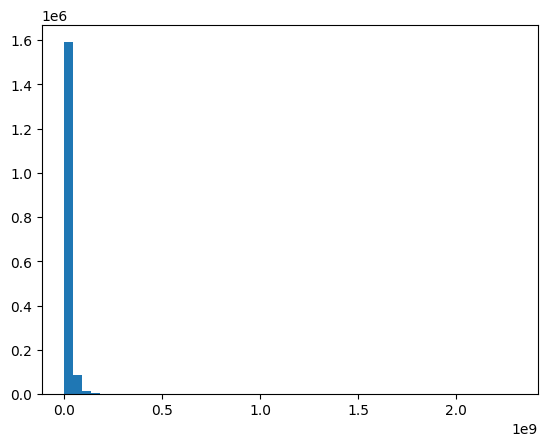

In [9]:
import matplotlib.pyplot as plt
plt.hist(df_trans_paris["price_per_square_meter"] , bins=50)
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# # remove outliers
# low = np.percentile(df_trans_paris["price_per_square_meter"], 1)
# high = np.percentile(df_trans_paris["price_per_square_meter"], 99)

# filtered = df_trans_paris["price_per_square_meter"][
#     (df_trans_paris["price_per_square_meter"] >= low) &
#     (df_trans_paris["price_per_square_meter"] <= high)
# ]

# # raw distribution
# plt.hist(filtered, bins=50)
# plt.title("Price per square meter")
# plt.show()

# # log distribution
# plt.hist(np.log(filtered), bins=50)
# plt.title("Log of price per square meter")
# plt.show()

In [11]:
df_trans_paris

,trans_date,trans_year,trans_month,price,prop_type,prop_year_harm,prop_loc_dep,prop_loc_citycode,prop_loc_x,prop_loc_y,...,s_land_artif,s_land_agri,s_land_nat,n_garage,n_pool,n_terrace,n_attic,n_basmt,n_otherannex,price_per_square_meter
1323,2024-05-03,2024,5,101258.225109,1,1900,93,93048,2.455521,48.870076,...,133,0,0,1,0,1,1,1,1,1.316357e+07
2268,2016-09-10,2016,9,108551.691624,1,1979,77,77495,2.629716,48.585046,...,1258,0,0,1,1,0,0,1,2,1.356896e+07
2269,2023-09-02,2023,9,103358.330665,1,1900,77,77114,2.658776,48.725826,...,1271,0,0,2,1,0,1,2,0,1.260972e+07
2270,2011-08-18,2011,8,631713.329846,1,1977,77,77089,2.944329,48.508707,...,1146,0,0,1,1,2,0,1,0,8.022759e+07
2271,2015-03-02,2015,3,174613.395677,1,1971,77,77269,2.702652,48.548586,...,1373,440,0,1,1,1,1,1,0,2.304897e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999630,2019-02-21,2019,2,527108.287905,2,2006,94,94081,2.405886,48.803895,...,0,0,0,1,0,0,0,1,0,4.006023e+07
9999631,2010-02-24,2010,2,737220.536014,2,1955,94,94028,2.454405,48.782943,...,0,0,0,0,0,0,1,0,0,5.602876e+07
9999632,2012-08-08,2012,8,693005.084919,2,1972,94,94041,2.399430,48.813493,...,0,0,0,0,0,0,1,0,0,5.266839e+07
9999633,2019-12-04,2019,12,203212.712728,2,1970,94,94022,2.414722,48.765459,...,0,0,0,1,0,0,1,0,0,1.544417e+07


In [12]:
df_trans_paris["price_per_square_meter"]> 2000000

1323       True
2268       True
2269       True
2270       True
2271       True
           ... 
9999630    True
9999631    True
9999632    True
9999633    True
9999634    True
Name: price_per_square_meter, Length: 1696331, dtype: bool

In [13]:
print((f"{df_trans_paris.shape[0]} rows before filtering"))

# mask_above = df_trans_paris["price_per_square_meter"]> 200000
# mask_below = df_trans_paris["price_per_square_meter"] < 100

# mask = mask_above | mask_below


# df_trans_paris = df_trans_paris.loc[mask]


df_trans_paris = df_trans_paris[
    (df_trans_paris["price_per_square_meter"]> 200000) |
    (df_trans_paris["price_per_square_meter"] < 100)
]



print((f"{df_trans_paris.shape[0]} rows after deterministic filtering"))

Q1 = np.percentile(df_trans_paris["price_per_square_meter"], 25)
Q3 = np.percentile(df_trans_paris["price_per_square_meter"], 75)
iqr = Q3 - Q1


df_df_trans_paris = df_trans_paris[
    (df_trans_paris["price_per_square_meter"] >= Q1) |
    (df_trans_paris["price_per_square_meter"] <= Q3)
]

print((f"{df_trans_paris.shape[0]} rows after deterministic and statistic filtering"))


1696331 rows before filtering
1696301 rows after deterministic filtering
1696301 rows after deterministic and statistic filtering


In [17]:
df_trans_paris.shape

(1696301, 44)

In [18]:
# Deleting rows wth missing values

df_filtered_outlier = df_trans_paris.dropna()
df_filtered_outlier.shape

(1694613, 44)

## 2.1.2 Preparation of the features (variables X of the ML model)